<a href="https://colab.research.google.com/github/zohaibahmedshaikh32-coder/Ml-lab6/blob/main/MlLab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#task1
# Import initial libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
cancer_data = load_breast_cancer()

# Convert to a Pandas DataFrame for easy manipulation
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.Series(cancer_data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nTarget Classes:", cancer_data.target_names)
X.head()

Dataset Shape: (569, 30)

Target Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#task2
from sklearn.preprocessing import StandardScaler

# Check for missing values
print("Missing values in features:", X.isnull().sum().sum())

# Feature Scaling (Crucial for SVM as it depends on distance calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData successfully scaled using StandardScaler.")

Missing values in features: 0

Data successfully scaled using StandardScaler.


In [ ]:
#tsk3
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 455 samples
Testing set size: 114 samples


In [ ]:
#task4
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

# Initialize SVM and GridSearchCV
svm_model = SVC()
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit Grid Search to training data
print("Running Grid Search...")
grid_search.fit(X_train, y_train)

# Display best parameters and best cross-validation score
print("\nBest Parameters Found:")
print(grid_search.best_params_)
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

Running Grid Search...

Best Parameters Found:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best Cross-Validation Accuracy: 98.02%


In [ ]:
#task5
# Get the best model from Grid Search
best_svm = grid_search.best_estimator_

# Make predictions on the unseen test set
y_pred = best_svm.predict(X_test)

print("Predictions successfully generated for the test set.")

Predictions successfully generated for the test set.


In [ ]:
#task6
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Summary Metrics
print("=== SVM MODEL PERFORMANCE METRICS ===")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print("\n" + "="*38 + "\n")

# Detailed Classification Report
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=cancer_data.target_names))

=== SVM MODEL PERFORMANCE METRICS ===
Accuracy : 98.25%
Precision: 98.61%
Recall   : 98.61%
F1-Score : 98.61%


Full Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



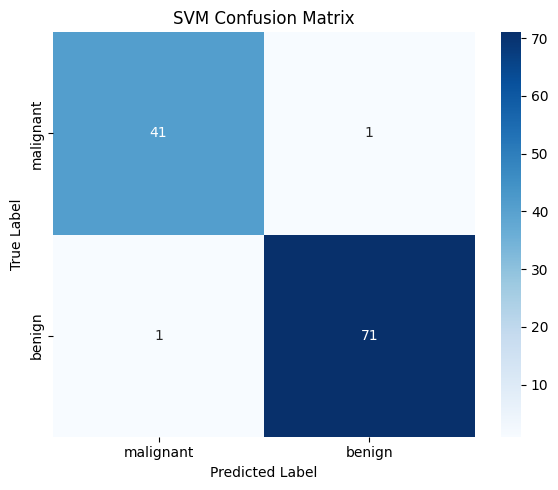

In [ ]:
#task7
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cancer_data.target_names,
    yticklabels=cancer_data.target_names
)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()